In [ ]:
import sys
from pathlib import Path
import yaml

import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


In [8]:
emb_folder = project_root / "data" / "processed" / "ProtLM_embeddings_with_labels_layer8"
splits_path = project_root / "data" / "processed" / "mmseqs_splits.csv"
splits = pd.read_csv(splits_path)
split_map = dict(zip(splits["gene_key"], splits["split"]))



In [9]:
# Use lists to collect tensors
train_emb, train_y = [], []
val_emb, val_y = [], []
test_emb, test_y = [], []

count = 0

for file in emb_folder.glob("*.pt"):
    data = torch.load(file, map_location="cpu", weights_only=False)
    if not isinstance(data, dict) or "embeddings" not in data or "y" not in data:
        continue

    emb = data["embeddings"].float()
    y = data["y"] if isinstance(data["y"], torch.Tensor) else torch.tensor(data["y"], dtype=torch.long)
    
    for i, label in enumerate(data["group_labels"]):
        if label not in split_map:
            if count < 10:
                print(f"Label {label} not in split_map")
            count += 1
        else:
            split = split_map[label]
            if split == "train":
                train_emb.append(emb[i : i + 1])
                train_y.append(y[i : i + 1])
            elif split == "val":
                val_emb.append(emb[i : i + 1])
                val_y.append(y[i : i + 1])
            elif split == "test":
                test_emb.append(emb[i : i + 1])
                test_y.append(y[i : i + 1])
# Concatenate into single tensors per split
X_train = torch.cat(train_emb)
y_train = torch.cat(train_y, dim=0)
X_val = torch.cat(val_emb)
y_val = torch.cat(val_y, dim=0)
X_test = torch.cat(test_emb)
y_test = torch.cat(test_y, dim=0)

print("Before dropping no_data:")
print(f"Train X: {X_train.shape}, Train y: {y_train.shape}")
print(f"Val X: {X_val.shape}, Val y: {y_val.shape}")
print(f"Test X: {X_test.shape}, Test y: {y_test.shape}")
# Drop no_data (y == -1). 
# 0 = essential (always_essential+conditional)
# 1 = non_essential 
mask_train = y_train >= 0
X_train, y_train = X_train[mask_train], y_train[mask_train].clone()
y_train[y_train == 1] = 0
y_train[y_train == 2] = 1
mask_val = y_val >= 0
X_val, y_val = X_val[mask_val], y_val[mask_val].clone()
y_val[y_val == 1] = 0
y_val[y_val == 2] = 1
mask_test = y_test >= 0
X_test, y_test = X_test[mask_test], y_test[mask_test].clone()
y_test[y_test == 1] = 0
y_test[y_test == 2] = 1

print()
print("After dropping no_data:")
print(f"Train X: {X_train.shape}, Train y: {y_train.shape}")
unique, counts = torch.unique(y_train, return_counts=True)
print(f"ytrain counts: {dict(zip(unique.tolist(), counts.tolist()))}")
print(f"Val X: {X_val.shape}, Val y: {y_val.shape}")
print(f"Test X: {X_test.shape}, Test y: {y_test.shape}")


Before dropping no_data:
Train X: torch.Size([176745, 1152]), Train y: torch.Size([176745])
Val X: torch.Size([22180, 1152]), Val y: torch.Size([22180])
Test X: torch.Size([22105, 1152]), Test y: torch.Size([22105])

After dropping no_data:
Train X: torch.Size([142452, 1152]), Train y: torch.Size([142452])
ytrain counts: {0: 23451, 1: 119001}
Val X: torch.Size([17821, 1152]), Val y: torch.Size([17821])
Test X: torch.Size([17679, 1152]), Test y: torch.Size([17679])


### Most basic model

In [10]:
# Minimal MLP: one hidden layer. No dropout, no class weights, no project code.
input_dim = 1152
hidden_dim = 2048
n_classes = 2
batch_size = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, n_classes),
).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

# Training loop with validation each epoch (train vs val loss for plotting).

train_loss = []
val_loss = []

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    mean_train = total_loss / n_batches
    train_loss.append(mean_train)
    # Validation (no gradients)
    model.eval()
    val_total = 0.0
    val_batches = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            val_total += loss_fn(logits, y).item()
            val_batches += 1
    mean_val = val_total / val_batches if val_batches > 0 else 0.0
    val_loss.append(mean_val)
    print(f"Epoch {epoch}: train_loss = {mean_train:.4f}  val_loss = {mean_val:.4f}")

Epoch 0: train_loss = 0.4017  val_loss = 0.4042
Epoch 1: train_loss = 0.3747  val_loss = 0.4008
Epoch 2: train_loss = 0.3489  val_loss = 0.4130
Epoch 3: train_loss = 0.3175  val_loss = 0.4246
Epoch 4: train_loss = 0.2834  val_loss = 0.4566
Epoch 5: train_loss = 0.2495  val_loss = 0.5009
Epoch 6: train_loss = 0.2186  val_loss = 0.5455
Epoch 7: train_loss = 0.1961  val_loss = 0.5824
Epoch 8: train_loss = 0.1753  val_loss = 0.6356
Epoch 9: train_loss = 0.1607  val_loss = 0.6638


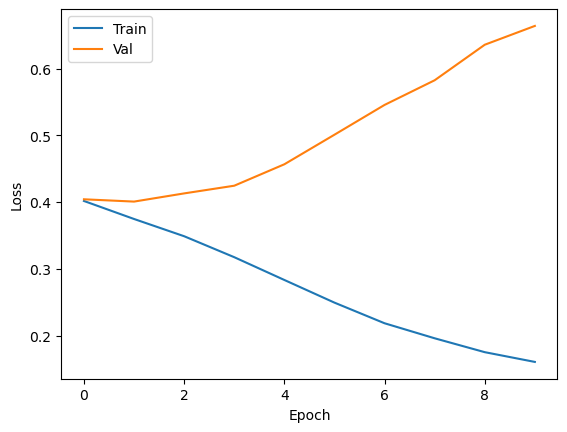

In [13]:
# Plot train vs val loss
import matplotlib.pyplot as plt
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### add normalization by organism

In [5]:
def normalize_embeddings_by_organism(X):
    # X is a tensor of shape (n_proteins, n_features)
    # return a tensor of shape (n_proteins, n_features)
    mean = X.mean(dim=0)
    std = X.std(dim=0)

    # zero variance handling
    std[std==0] = 1.0

    # normalize (X-mean) / std
    return (X - mean) / std



In [6]:
for file in emb_folder.glob("*.pt"):
    data = torch.load(file, map_location="cpu", weights_only=False)
    
    emb = normalize_embeddings_by_organism(data["embeddings"].float())
    y = data["y"] if isinstance(data["y"], torch.Tensor) else torch.tensor(data["y"], dtype=torch.long)

    for i, label in enumerate(data["group_labels"]):
        if label not in split_map:
            if count < 10:
                print(f"Label {label} not in split_map")
            count += 1
        else:
            split = split_map[label]
            if split == "train":
                train_emb.append(emb[i : i + 1])
                train_y.append(y[i : i + 1])
            elif split == "val":
                val_emb.append(emb[i : i + 1])
                val_y.append(y[i : i + 1])
            elif split == "test":
                test_emb.append(emb[i : i + 1])
                test_y.append(y[i : i + 1])
# Concatenate into single tensors per split
X_train = torch.cat(train_emb)
y_train = torch.cat(train_y, dim=0)
X_val = torch.cat(val_emb)
y_val = torch.cat(val_y, dim=0)
X_test = torch.cat(test_emb)
y_test = torch.cat(test_y, dim=0)

print("Before dropping no_data:")
print(f"Train X: {X_train.shape}, Train y: {y_train.shape}")
print(f"Val X: {X_val.shape}, Val y: {y_val.shape}")
print(f"Test X: {X_test.shape}, Test y: {y_test.shape}")
# Drop no_data (y == -1). 
# 0 = essential (always_essential+conditional)
# 1 = non_essential 
mask_train = y_train >= 0
X_train, y_train = X_train[mask_train], y_train[mask_train].clone()
y_train[y_train == 1] = 0
y_train[y_train == 2] = 1
mask_val = y_val >= 0
X_val, y_val = X_val[mask_val], y_val[mask_val].clone()
y_val[y_val == 1] = 0
y_val[y_val == 2] = 1
mask_test = y_test >= 0
X_test, y_test = X_test[mask_test], y_test[mask_test].clone()
y_test[y_test == 1] = 0
y_test[y_test == 2] = 1

print()
print("After dropping no_data:")
print(f"Train X: {X_train.shape}, Train y: {y_train.shape}")
unique, counts = torch.unique(y_train, return_counts=True)
print(f"ytrain counts: {dict(zip(unique.tolist(), counts.tolist()))}")
print(f"Val X: {X_val.shape}, Val y: {y_val.shape}")
print(f"Test X: {X_test.shape}, Test y: {y_test.shape}")

    

Before dropping no_data:
Train X: torch.Size([353490, 1152]), Train y: torch.Size([353490])
Val X: torch.Size([44360, 1152]), Val y: torch.Size([44360])
Test X: torch.Size([44210, 1152]), Test y: torch.Size([44210])

After dropping no_data:
Train X: torch.Size([284904, 1152]), Train y: torch.Size([284904])
ytrain counts: {0: 46902, 1: 238002}
Val X: torch.Size([35642, 1152]), Val y: torch.Size([35642])
Test X: torch.Size([35358, 1152]), Test y: torch.Size([35358])


In [43]:
unique_values, counts = torch.unique(y_train, return_counts=True)
for val, count in zip(unique_values.tolist(), counts.tolist()):
    print(f"Value {val}: {count} occurrences")

Value 0: 23451 occurrences
Value 1: 119001 occurrences


In [15]:
# Minimal MLP: one hidden layer. No dropout, no class weights, no project code.
input_dim = 1152
hidden_dim = 2048
n_classes = 2
batch_size = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, n_classes),
).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [ ]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

# Training loop with validation each epoch (train vs val loss for plotting).

train_loss = []
val_loss = []

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    mean_train = total_loss / n_batches
    train_loss.append(mean_train)
    # Validation (no gradients)
    model.eval()
    val_total = 0.0
    val_batches = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            val_total += loss_fn(logits, y).item()
            val_batches += 1
    mean_val = val_total / val_batches if val_batches > 0 else 0.0
    val_loss.append(mean_val)
    print(f"Epoch {epoch}: train_loss = {mean_train:.4f}  val_loss = {mean_val:.4f}")

Epoch 0: train_loss = 0.4010  val_loss = 0.4089
Epoch 1: train_loss = 0.3737  val_loss = 0.4096
Epoch 2: train_loss = 0.3464  val_loss = 0.4216
Epoch 3: train_loss = 0.3159  val_loss = 0.4359
Epoch 4: train_loss = 0.2817  val_loss = 0.4659
Epoch 5: train_loss = 0.2481  val_loss = 0.5056
Epoch 6: train_loss = 0.2196  val_loss = 0.5564
Epoch 7: train_loss = 0.1950  val_loss = 0.5853
Epoch 8: train_loss = 0.1765  val_loss = 0.6366
Epoch 9: train_loss = 0.1607  val_loss = 0.6684


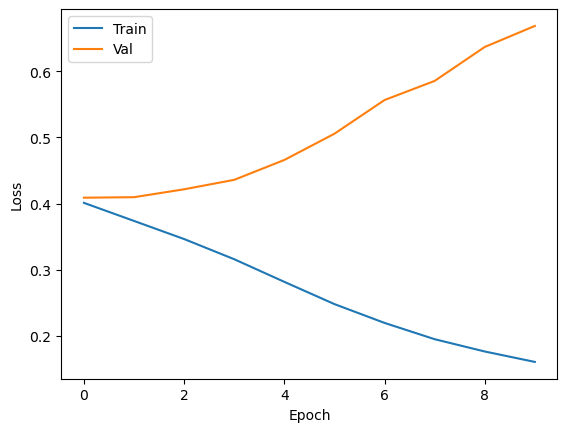

In [17]:
# Plot train vs val loss
import matplotlib.pyplot as plt
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [23]:
def plot_train_test(train_loss, val_loss):
    plt.plot(train_loss, label="Train")
    plt.plot(val_loss, label="Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

*** 
### Batch size

In [ ]:
# Minimal MLP: one hidden layer. No dropout, no class weights, no project code.
input_dim = 1152
hidden_dim_1 = 512
hidden_dim_2 = 2048
n_classes = 2
batch_size = 512

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim_1),
    nn.ReLU(),
    nn.Linear(hidden_dim_1, hidden_dim_2),
    nn.ReLU(),
    nn.Linear(hidden_dim_2, n_classes),
).to(device)
# weights are indexed by class index
class_weights = torch.Tensor([1.0, 0.5]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters())

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)

# Training loop with validation each epoch (train vs val loss for plotting).

train_loss = []
val_loss = []

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    n_batches = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1
    mean_train = total_loss / n_batches
    train_loss.append(mean_train)
    # Validation (no gradients)
    model.eval()
    val_total = 0.0
    val_batches = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            val_total += loss_fn(logits, y).item()
            val_batches += 1
    mean_val = val_total / val_batches if val_batches > 0 else 0.0
    val_loss.append(mean_val)
    print(f"Epoch {epoch}: train_loss = {mean_train:.4f}  val_loss = {mean_val:.4f}")

Epoch 0: train_loss = 0.5160  val_loss = 0.5079
Epoch 1: train_loss = 0.4732  val_loss = 0.5206
Epoch 2: train_loss = 0.4371  val_loss = 0.5399
Epoch 3: train_loss = 0.3959  val_loss = 0.5592
Epoch 4: train_loss = 0.3510  val_loss = 0.5960
Epoch 5: train_loss = 0.3014  val_loss = 0.7065
Epoch 6: train_loss = 0.2550  val_loss = 0.7976
Epoch 7: train_loss = 0.2163  val_loss = 0.9027
Epoch 8: train_loss = 0.1818  val_loss = 1.1127
Epoch 9: train_loss = 0.1553  val_loss = 1.2571


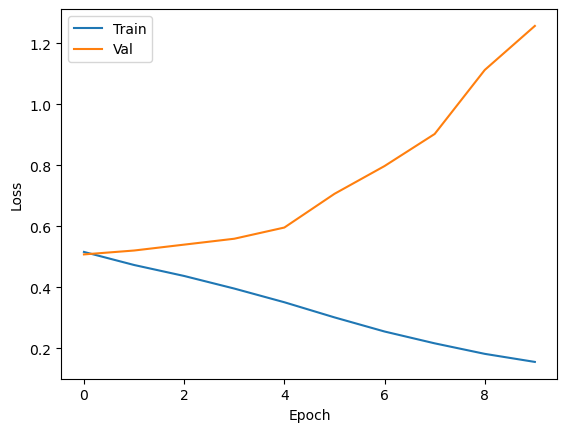

In [36]:
plot_train_test(train_loss, val_loss)

***
### Running summary of results

1. Normalization by organism
For this we normalized the contextualized embeddings by mean and std of the organisms proteome (i.e. across all the proteins for that organism). This was done before splitting the data so I'm not sure if that normalization only has to be done for the training set after the split is done. Not sure how exactly that would be done since we don't split by organism.

2. Increasing batch size
Increasing batch size had little effect on the train/val curves. We're still getting almost no decrease in validation throughout the epochs. This may be a result of having a bad labeling method for our classes since the thresholds for essential or non-essential were essentially randomly chosen.

3. Added another hidden layer
I went from [2048] to [512, 2048]. This also seemed to have little effect. The validation curve still doesn't decrease at all with any epoch. This seems like a deeper problem than overfitting since we're not getting any decrease in validation no matter what changes we seems to make.

4. 